Material for the book Probability and Statistics for Data Science. A free preprint, videos, code, slides and solutions to exercises are available at https://www.ps4ds.net/

Prediction of rare events (catastrophically large fires) using a parametric Pareto distribution.\
Topics and relevant videos: [Maximum likelihood for continuous parametric models](https://youtu.be/kRZR9Amyc64)

Author: Carlos Fernandez-Granda

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fontsize = 20

In [4]:
# Load the data
data = np.load("../data/fires.npz")

fires_train = data["fires_train"]
fires_test = data["fires_test"]

n_train = len(fires_train)
n_test = len(fires_test)

In [5]:
n_train = len(fires_train)
n_test = len(fires_test)

catastrophic_threshold = 1e5
n_fires_pred = 23 * 70000 # Assumed total fires in next 23 years
empirical_prob = np.sum(fires_train > catastrophic_threshold) / n_train
predicted_fires_empirical_prob = n_fires_pred * empirical_prob
print("Predicted catastrophic fires via empirical pmf:",predicted_fires_empirical_prob)
print("True catastrophic fires",np.sum(fires_test > catastrophic_threshold))

Predicted catastrophic fires via empirical pmf: 0.0
True catastrophic fires 178


In [6]:
# Exponential model
lambda_ml = 1.0 / np.mean(fires_train)
prob_exponential = np.exp(-lambda_ml * catastrophic_threshold)
predicted_fires_exponential = n_fires_pred * prob_exponential
print("Predicted catastrophic fires via exponential model:",predicted_fires_exponential)

Predicted catastrophic fires via exponential model: 0.0


In [7]:
ratio_1 = np.sum(fires_train > 1) / np.sum(fires_train > 10) 
ratio_2 = np.sum(fires_train > 10) / np.sum(fires_train > 100) 
ratio_3 = np.sum(fires_train > 100) / np.sum(fires_train > 1000)  
print(np.around(ratio_1,2),np.around(ratio_2,2),np.around(ratio_3,2))

3.25 5.77 5.75


In [8]:
# Fit Pareto model via maximum likelihood estimation
b_ml = np.min(fires_train)
alpha_ml = n_train / (np.sum(np.log(fires_train/b_ml)))

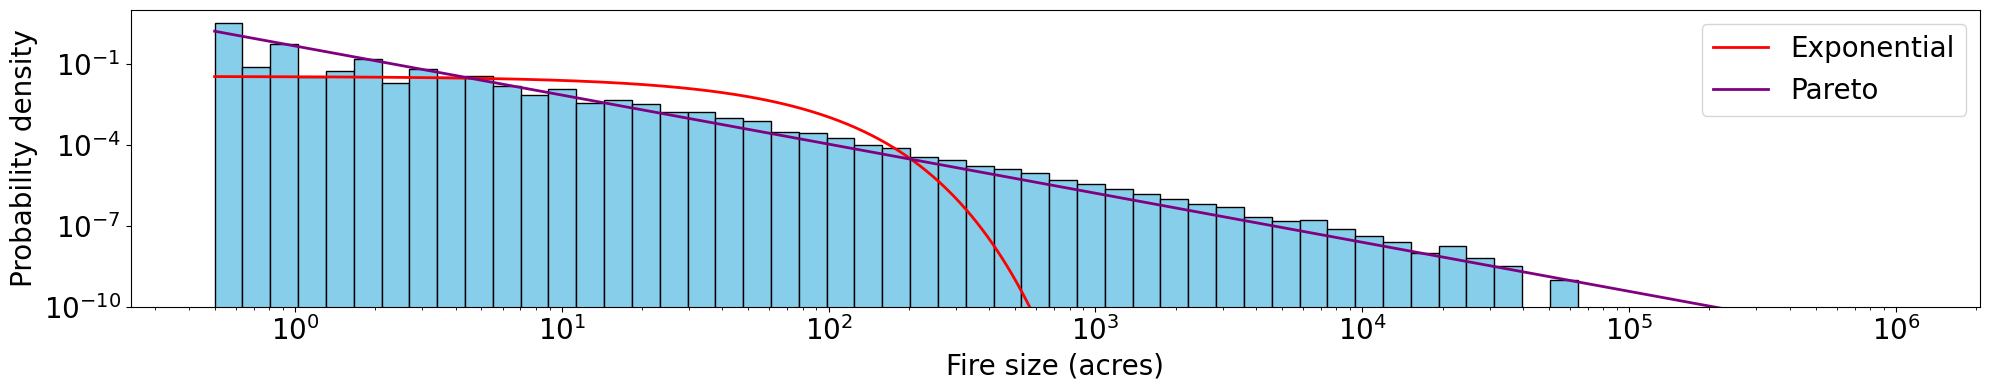

In [9]:
x = np.geomspace(b_ml, catastrophic_threshold*10, 1000)

# 2. Compute PDFs
pdf_exp = lambda_ml * np.exp(-lambda_ml * x)
pdf_pareto = alpha_ml * (b_ml**alpha_ml) / (x**(alpha_ml + 1))

# 3. Create log-spaced bins for histogram
bins = np.geomspace(np.min(fires_train), np.max(fires_train), 50)

fig, ax = plt.subplots(1, 1, figsize=(20, 4), sharex=True)

# Plot histogram with log-spaced bins
ax.hist(
    fires_train,
    bins=bins,
    color="skyblue",
    edgecolor="black",
    density=True,
    log=True,
)

# # Plot curves
ax.plot(x, pdf_exp, color="red", linewidth=2, label="Exponential")
ax.plot(x, pdf_pareto, color="purple", linewidth=2, label="Pareto")

# # 4. Set both axes to log scale
ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_ylim([1e-10,10])

ax.set_xlabel("Fire size (acres)", fontsize=fontsize)
ax.set_ylabel("Probability density", fontsize=fontsize)
ax.tick_params(axis="both", labelsize=fontsize)

ax.legend(fontsize=fontsize)

# Adjust layout and display
plt.tight_layout()

In [10]:
prob_pareto = (b_ml/catastrophic_threshold)**alpha_ml
predicted_fires_pareto = n_fires_pred * prob_pareto
print("Predicted catastrophic fires via Pareto model:",np.around(predicted_fires_pareto,2))

Predicted catastrophic fires via Pareto model: 73.73
